In [24]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from astropy.constants import c

In [13]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [59]:
dat_sec_1 = pd.read_csv('./inputs/larger_test_5000_1_deflector.csv').sort_values('redshift')
dat_sec_2 = pd.read_csv('./inputs/larger_test_5000_2_deflector.csv').sort_values('redshift')
dat_sec_3 = pd.read_csv('./inputs/larger_test_5000_3_deflector.csv').sort_values('redshift')
dat_sec_4 = pd.read_csv('./inputs/larger_test_5000_4_deflector.csv').sort_values('redshift')

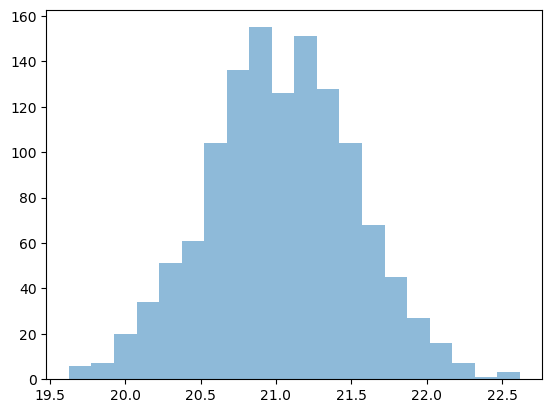

In [60]:
plt.hist(dat_sec_1['AB_magnitude'], bins=20, alpha=0.5, label='Section 1')
plt.show()

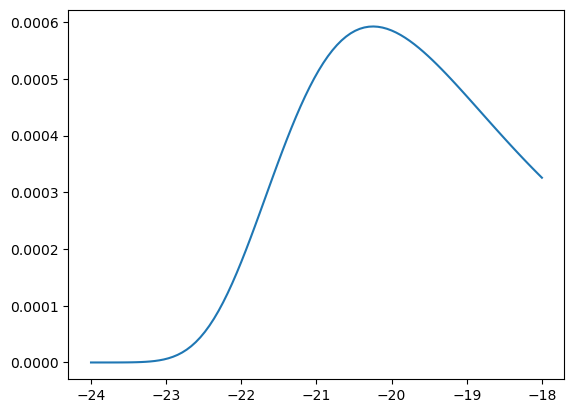

In [ ]:
def abs_M_scheter(M, M_star=-21.0, alpha=-0.5):
    return 0.4 * np.log(10) * 1.5e-3 * 10**(0.4*(alpha+1)*(M_star-M)) * np.exp(-10**(0.4*(M_star-M)))

M_values = np.linspace(-24, -18, 100)
schechter_values = abs_M_scheter(M_values)

plt.plot(M_values, schechter_values)
plt.show()

In [61]:
DL = cosmo.luminosity_distance(dat_sec_1['redshift']).value  # in Mpc

mu = 5*np.log10(DL*1e6) - 5

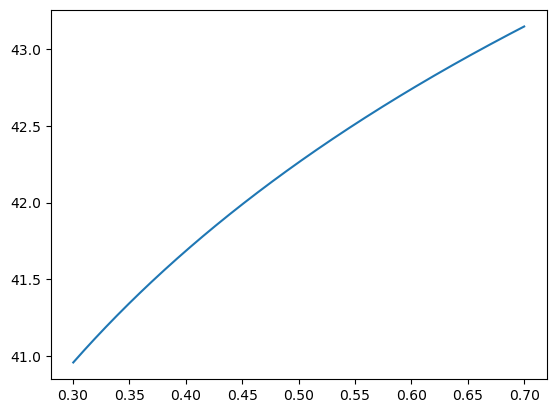

In [62]:
plt.plot(dat_sec_1['redshift'], mu)

In [ ]:
import photometry

VIS_filter_passband = photometry.Passband(file='VIS.Euclid.pb')
VIS_filter = np.array([VIS_filter_passband.lam(unit=u.AA).value, VIS_filter_passband.y])

elliptical_SED = np.loadtxt('./inputs/SEDs/Ell13_template_norm.csv', unpack=True)

elliptical_SED.shape, VIS_filter.shape

((2, 1146), (2, 808))

In [64]:
from scipy.integrate import trapezoid

def redshift_sed(SED, z):
    return np.array([SED[0] * (1 + z), SED[1] / (1 + z)])


def get_weighted_mean_flux(SED, filter_throughput):
    interp_filter = np.interp(
        SED[0],
        filter_throughput[0],
        filter_throughput[1],
        left=0.0,
        right=0.0,
    )
    numerator = trapezoid(SED[1] * interp_filter * SED[0], SED[0])
    denominator = trapezoid(interp_filter * SED[0], SED[0])
    return numerator / denominator


def get_ab_magnitude(SED, filter_throughput):
    mean_flux = get_weighted_mean_flux(SED, filter_throughput)
    effective_wavelength = trapezoid(
        filter_throughput[0] * filter_throughput[1],
        filter_throughput[0],
    ) / trapezoid(filter_throughput[1], filter_throughput[0])
    f_nu = mean_flux * effective_wavelength ** 2 / c.to(u.AA / u.s).value
    return -2.5 * np.log10(f_nu) - 48.6


rest_vis_ab_mag = get_ab_magnitude(elliptical_SED, VIS_filter)


def vis_k_correction(z):
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    k_vals = np.array([
        get_ab_magnitude(redshift_sed(elliptical_SED, zi), VIS_filter) - rest_vis_ab_mag
        for zi in z_arr
    ])
    return k_vals[0] if np.ndim(z) == 0 else k_vals


all_redshifts = np.concatenate([
    dat_sec_1['redshift'].to_numpy(),
    dat_sec_2['redshift'].to_numpy(),
    dat_sec_3['redshift'].to_numpy(),
    dat_sec_4['redshift'].to_numpy(),
])
unique_redshifts = np.sort(np.unique(all_redshifts))
k_corrections_VIS = vis_k_correction(unique_redshifts)

for dataframe in [dat_sec_1, dat_sec_2, dat_sec_3, dat_sec_4]:
    dataframe['k_correction_VIS'] = vis_k_correction(dataframe['redshift'].to_numpy())

k_correction_table = pd.DataFrame({
    'redshift': unique_redshifts,
    'k_correction_VIS': k_corrections_VIS,
})

k_correction_table.head()

,redshift,k_correction_VIS
0,0.300026,0.290388
1,0.300074,0.290440
2,0.300174,0.290548
3,0.300183,0.290558
4,0.300242,0.290622


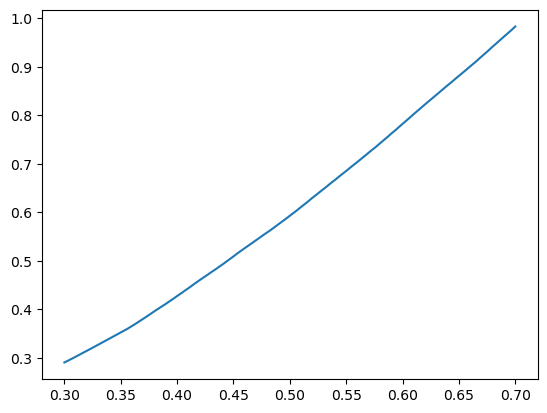

In [65]:
plt.plot(k_correction_table['redshift'], k_correction_table['k_correction_VIS'])

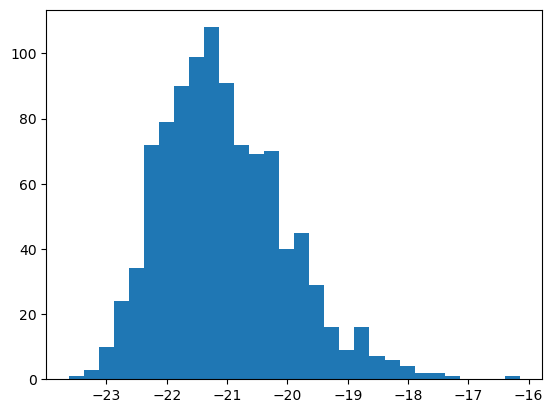

In [84]:
def sample_schechter(num_points=1, alpha=0.5, M_star=-21):

    k=alpha+1

    x = np.random.gamma(k, 1, num_points)

    return M_star - 2.5*np.log10(x)

plt.hist(sample_schechter(1000), bins=30)
plt.show()


100%|██████████| 1250/1250 [00:00<00:00, 15543.76it/s]


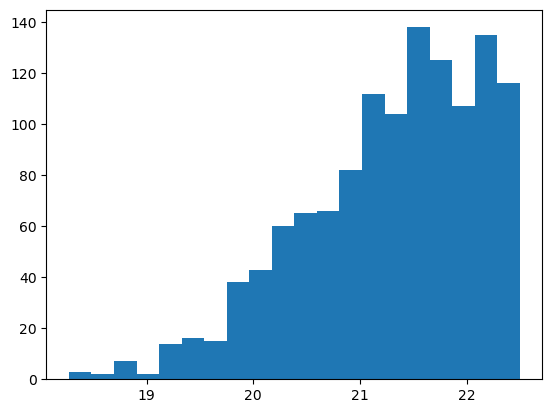

In [92]:
from tqdm import tqdm
aparent_magnitude = []

for k_corr, mu_value in tqdm(zip(dat_sec_1['k_correction_VIS'], mu), total=len(mu)):
    M_value = 100
    while M_value + k_corr + mu_value > 22.5:
        M_value = sample_schechter()[0]

    aparent_magnitude.append(M_value + k_corr + mu_value)
    
#plt.plot(dat_sec_1['redshift'], aparent_magnitude, '.')
plt.hist(aparent_magnitude, bins=20)
plt.show()